# Pump Calibration

Goal: Given pulse volumn, get the pulse duration

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
df = pd.read_csv("pump_flow_rate_pulse.csv")
df


,on_delay_ms,n_pulse,weight_g
0,100,20,3.25
1,200,20,5.80
2,300,20,8.54
3,400,20,11.05
4,500,20,13.88
...,...,...,...
71,200,40,11.75
72,200,40,11.74
73,200,40,11.88
74,200,40,11.88


In [3]:
df["weight_per_pulse"] = df["weight_g"] / df["n_pulse"] 
df["flow_rate_g_per_s"] = df["weight_g"] / df["on_delay_ms"] / df["n_pulse"] * 1000
df["flow_rate_g_per_ms"] = df["weight_g"] / df["on_delay_ms"] / df["n_pulse"]
df

,on_delay_ms,n_pulse,weight_g,weight_per_pulse,flow_rate_g_per_s,flow_rate_g_per_ms
0,100,20,3.25,0.16250,1.625000,0.001625
1,200,20,5.80,0.29000,1.450000,0.001450
2,300,20,8.54,0.42700,1.423333,0.001423
3,400,20,11.05,0.55250,1.381250,0.001381
4,500,20,13.88,0.69400,1.388000,0.001388
...,...,...,...,...,...,...
71,200,40,11.75,0.29375,1.468750,0.001469
72,200,40,11.74,0.29350,1.467500,0.001468
73,200,40,11.88,0.29700,1.485000,0.001485
74,200,40,11.88,0.29700,1.485000,0.001485


In [4]:
np.mean(df["flow_rate_g_per_ms"])

np.float64(0.0014759581505847952)

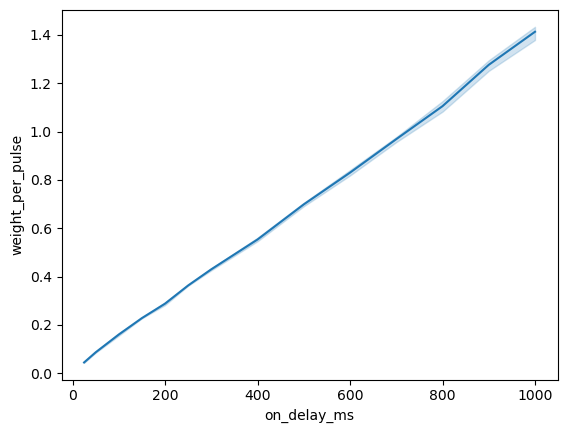

In [5]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="weight_per_pulse"
)
plt.show()

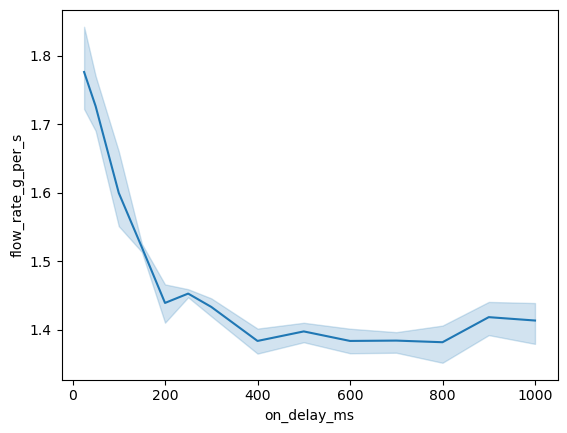

In [6]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_s",
    errorbar=("ci", 95)
)
plt.show()

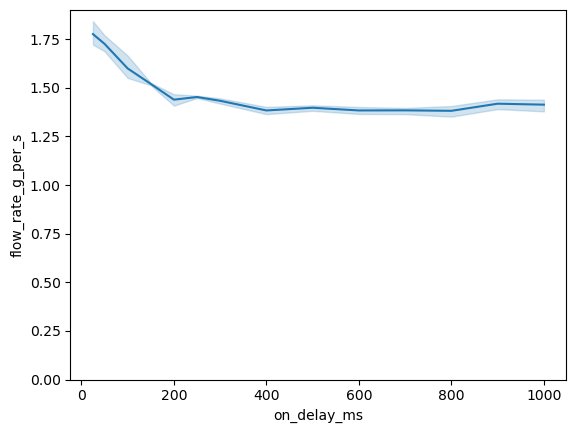

In [7]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_s",
    errorbar=("ci", 95)
)
plt.ylim([0, 1.9])
plt.show()

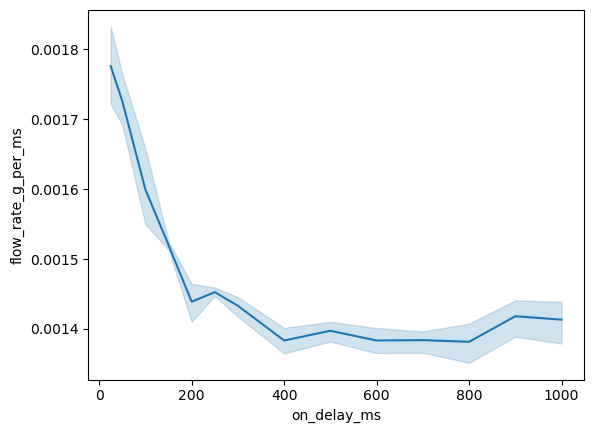

In [8]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_ms",
    errorbar=("ci", 95)
)
plt.show()

## Linear Fit

In [9]:
XX = df["on_delay_ms"].to_numpy()

In [10]:
YY = df["weight_per_pulse"].to_numpy()

In [11]:
def lin_fun(a, b):
    return lambda x: a*x + b

def lin_fit(x):
    a, b = x
    return (lin_fun(a, b)(XX)- YY)

sol = sp.optimize.least_squares(lin_fit, [0, 0])
sol

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-1.187e-02 -8.935e-04 ... -7.893e-03 -5.143e-03]
           x: [ 1.385e-03  1.216e-02]
        cost: 0.011805509666027345
         jac: [[ 1.000e+02  1.000e+00]
               [ 2.000e+02  1.000e+00]
               ...
               [ 2.000e+02  1.000e+00]
               [ 2.000e+02  1.000e+00]]
        grad: [-2.671e-11 -4.764e-14]
  optimality: 2.6710633704851716e-11
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 2
        njev: 2

In [12]:
lin_best_fit = lin_fun(*sol.x)

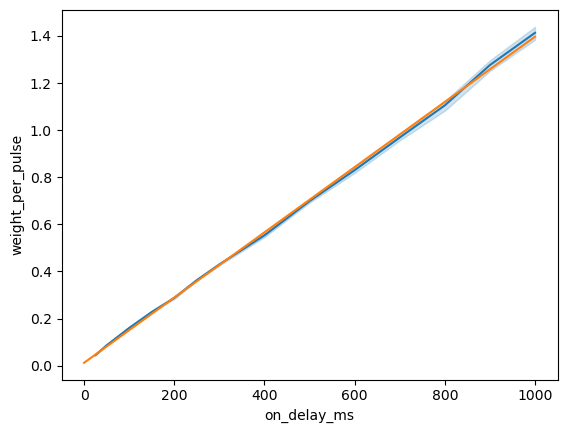

In [13]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="weight_per_pulse",
    errorbar=("ci", 95)
)
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, lin_best_fit(XXXX))
plt.show()

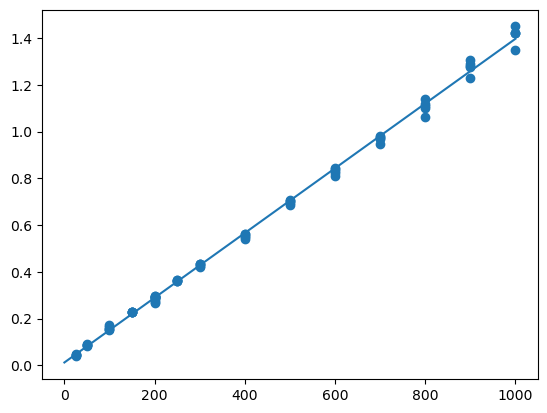

In [14]:
plt.figure(dpi=100)
plt.scatter(df["on_delay_ms"], df["weight_per_pulse"])
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, lin_best_fit(XXXX))
plt.show()

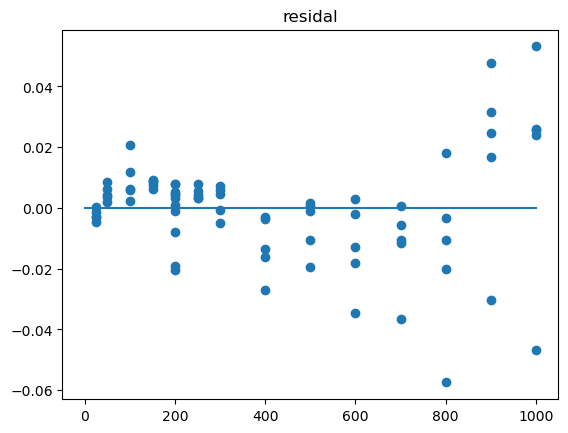

In [15]:
plt.figure(dpi=100)
plt.scatter(df["on_delay_ms"], df["weight_per_pulse"] - lin_best_fit(df["on_delay_ms"]))
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, lin_best_fit(XXXX) - lin_best_fit(XXXX))
plt.title("residal")
plt.show()

## Fit Pump Curve

In [16]:
XX = df["on_delay_ms"].to_numpy()

In [17]:
YY = df["flow_rate_g_per_ms"].to_numpy()

In [ ]:
def exp_fun(a, b, tau):
    return lambda x: a*np.exp(tau*x) + b

def exp_fit(x):
    a, b, tau = x
    return (exp_fun(a, b, tau)(XX)- YY)


In [19]:
sol = sp.optimize.least_squares(exp_fit, [0, 0, 0])
sol

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-4.052e-05  1.431e-05 ... -2.069e-05 -6.942e-06]
           x: [ 5.131e-04  1.392e-03 -9.825e-03]
        cost: 6.36464213180425e-08
         jac: [[ 3.744e-01  1.000e+00  1.921e-02]
               [ 1.401e-01  1.000e+00  1.438e-02]
               ...
               [ 1.401e-01  1.000e+00  1.438e-02]
               [ 1.401e-01  1.000e+00  1.438e-02]]
        grad: [ 1.188e-11  1.462e-10  5.666e-10]
  optimality: 5.665942456293578e-10
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 108
        njev: 90

In [20]:
a, b, tau = sol.x
print(f"{a=}, {b=}, {tau=}")

a=np.float64(0.0005130762486517596), b=np.float64(0.0013924014976105287), tau=np.float64(-0.009825281966288141)


In [ ]:
exp_best_fit = exp_fun(*sol.x)

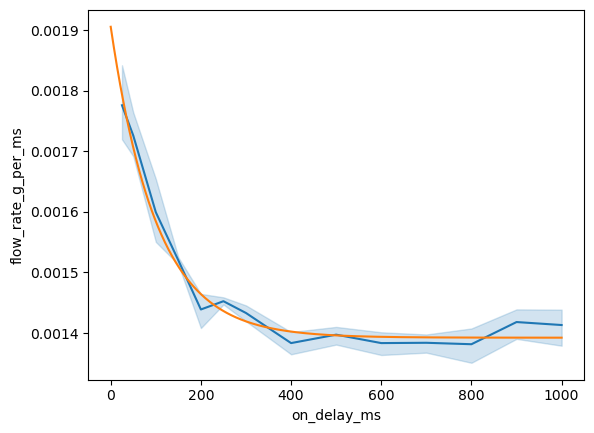

In [22]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_ms",
    errorbar=("ci", 95)
)
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, exp_best_fit(XXXX))
plt.show()

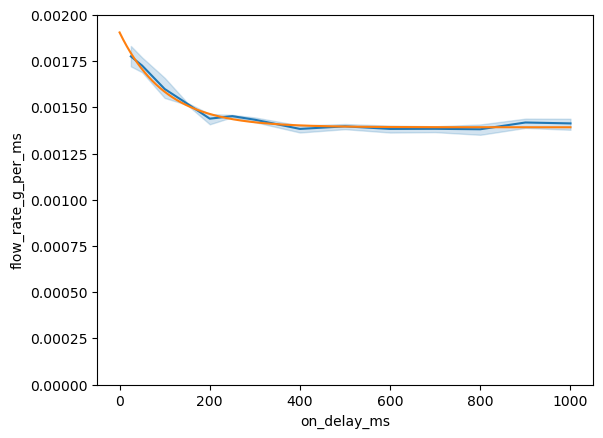

In [23]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_ms",
    errorbar=("ci", 95)
)
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, exp_best_fit(XXXX))
plt.ylim([0, 0.002])
plt.show()

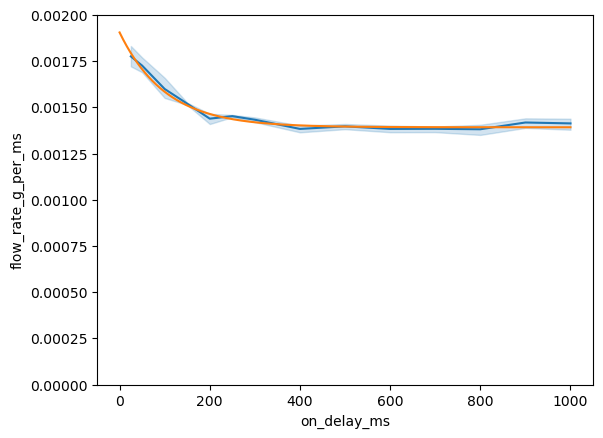

In [24]:
plt.figure(dpi=100)
sns.lineplot(
    df, 
    x="on_delay_ms",
    y="flow_rate_g_per_ms",
    errorbar=("ci", 95)
)
XXXX = np.linspace(0, 1000, 1000)
plt.plot(XXXX, exp_best_fit(XXXX))
plt.ylim([0, 0.002])
plt.show()